In [49]:
from src.dataloading import EpiDataLoader, DeepDataLoader, ShallowDataLoader
from src.utils import get_data_env
from src.models import NodeRFModel

disease_name    = 'influenza'
nuts_level      = 'nuts3'
min_date        = '2006-05-15'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False


horizon_size    = 4
horizon_leadtime= 3
sequence_length = 1
lags            = 4


epidata_loader_basis = ShallowDataLoader(disease_name, get_data_env(), nuts_level=nuts_level, min_date=min_date,max_date=max_date, include_population=False, horizon_size = horizon_size, horizon_leadtime = horizon_leadtime, sequence_length=sequence_length, split_berlin=split_berlin)
epidata_loader_basis.add_time_features()
epidata_loader_basis.log_transform_target()
epidata_loader_basis.set_splits(split_trainval, split_valtest)
epidata_loader_basis.normalize()
epidata_loader_basis.add_lagged_features(lags = lags)
epidata_loader_basis.finalize()

epidata_loader_basis.construct_dataloaders()

Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-03-27 (+7 weeks)
berlin districts removed


✓ Initialized 4 RF model
Validation loss for horizon incidence_h0: RMSE = 0.8276, MAE = 0.3699
Training RMSE: 0.5811 - Validation RMSE: 0.8276
Validation loss for horizon incidence_h1: RMSE = 0.8971, MAE = 0.4054
Training RMSE: 0.6231 - Validation RMSE: 0.8971
Validation loss for horizon incidence_h2: RMSE = 0.9425, MAE = 0.4268
Training RMSE: 0.6352 - Validation RMSE: 0.9425
Validation loss for horizon incidence_h3: RMSE = 1.5732, MAE = 0.7487
Training RMSE: 0.6668 - Validation RMSE: 1.5732
Training complete!


/home/de-schrijvers/projects/germany_gnn/src/models/shallow/node_rf.py:205: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  evaluation_df.loc[:,'incidence']  = y.values
/home/de-schrijvers/projects/germany_gnn/src/models/shallow/node_rf.py:206: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  evaluation_df.loc[:,'pred']       = preds
/home/de-schrijvers/projects/germany_gnn/src/models/shallow/node_rf.py:205: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .lo

(<Figure size 1600x1000 with 2 Axes>,
 array([<Axes: title={'center': 'National incidence rate (per 10000)'}, ylabel='incidence'>,
        <Axes: title={'center': 'Predictions node: 0'}, ylabel='incidence'>],
       dtype=object))

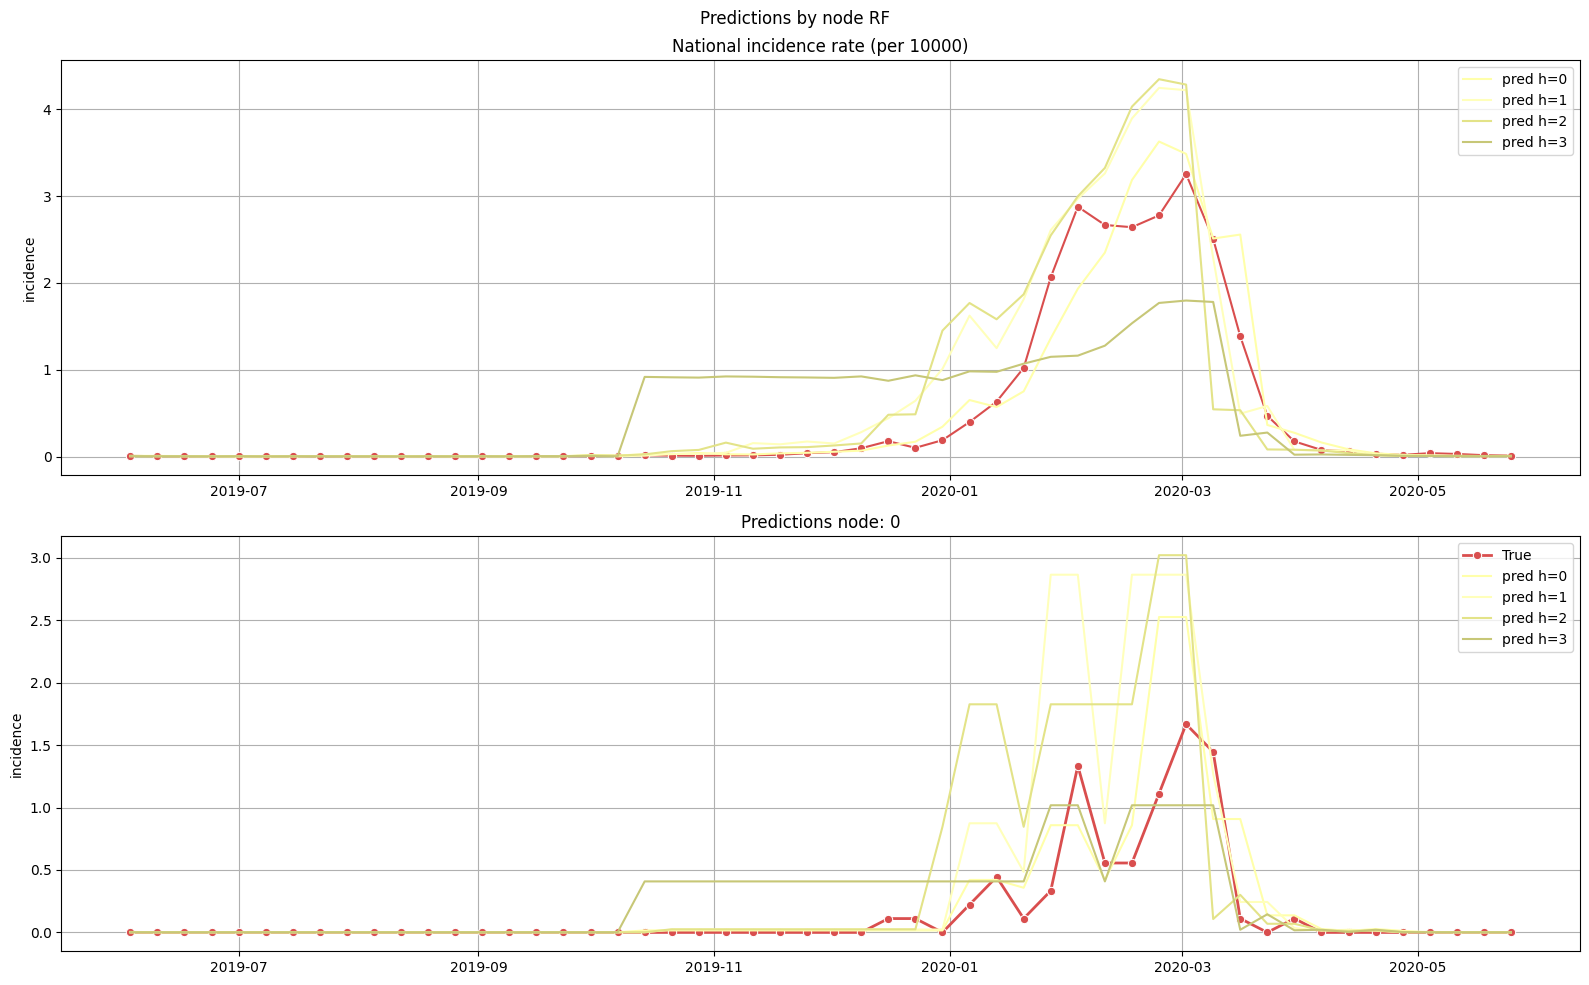

In [ ]:
rfmodel = NodeRFModel(epidata_loader_basis, name = 'node RF')
rfmodel.set_global_hparams()
rfmodel.set_model_hparams(n_estimators=1)
rfmodel.train()
rfmodel.forecast('test')


In [63]:
rfmodel.evaluation_datasets['test']['nontransformed']['horizon_0']

,timestamp,node,timestamp_sin,timestamp_cos,incidence_lag3,incidence_lag4,incidence_lag5,incidence_lag6,incidence_h0,train,val,test,incidence,pred
272800,2019-06-03,0,0.354605,-0.935016,0.000000,0.000000,0.110909,0.110909,-0.323578,False,False,True,0.000000,0.001136
272801,2019-06-03,1,0.354605,-0.935016,0.162078,0.040520,0.121559,0.648314,-0.323578,False,False,True,0.000000,0.027286
272802,2019-06-03,2,0.354605,-0.935016,0.000000,0.046183,0.046183,0.184732,-0.323578,False,False,True,0.000000,0.012761
272803,2019-06-03,3,0.354605,-0.935016,0.000000,0.000000,0.000000,0.000000,-0.323578,False,False,True,0.000000,0.001136
272804,2019-06-03,4,0.354605,-0.935016,0.075079,0.000000,0.000000,0.000000,-0.323578,False,False,True,0.000000,0.027286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
293595,2020-05-25,395,0.508531,-0.861044,0.000000,0.000000,0.000000,0.000000,-0.323578,False,False,True,0.000000,0.001136
293596,2020-05-25,396,0.508531,-0.861044,0.000000,0.000000,0.000000,0.000000,-0.323578,False,False,True,0.000000,0.001136
293597,2020-05-25,397,0.508531,-0.861044,0.000000,0.000000,0.000000,0.000000,-0.323578,False,False,True,0.000000,0.001136
293598,2020-05-25,398,0.508531,-0.861044,0.000000,0.000000,0.000000,0.000000,0.329046,False,False,True,0.206894,0.001136


In [76]:
node_idx = [26]

final_df = epidata_loader_basis.data['final']

final_df_node = final_df[final_df['node'].isin(node_idx)]
final_df_node = final_df_node[final_df_node['test']]

<Axes: xlabel='timestamp', ylabel='incidence_h0'>

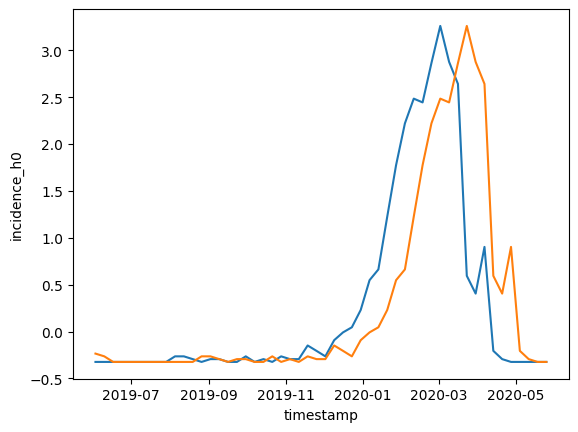

In [77]:
sns.lineplot(final_df_node, x = 'timestamp', y ='incidence_h0')
sns.lineplot(final_df_node, x = 'timestamp', y ='incidence_lag3')

(<Figure size 1600x1000 with 2 Axes>,
 array([<Axes: title={'center': 'National incidence rate (per 10000)'}, ylabel='incidence'>,
        <Axes: title={'center': 'Predictions node: 0'}, ylabel='incidence'>],
       dtype=object))

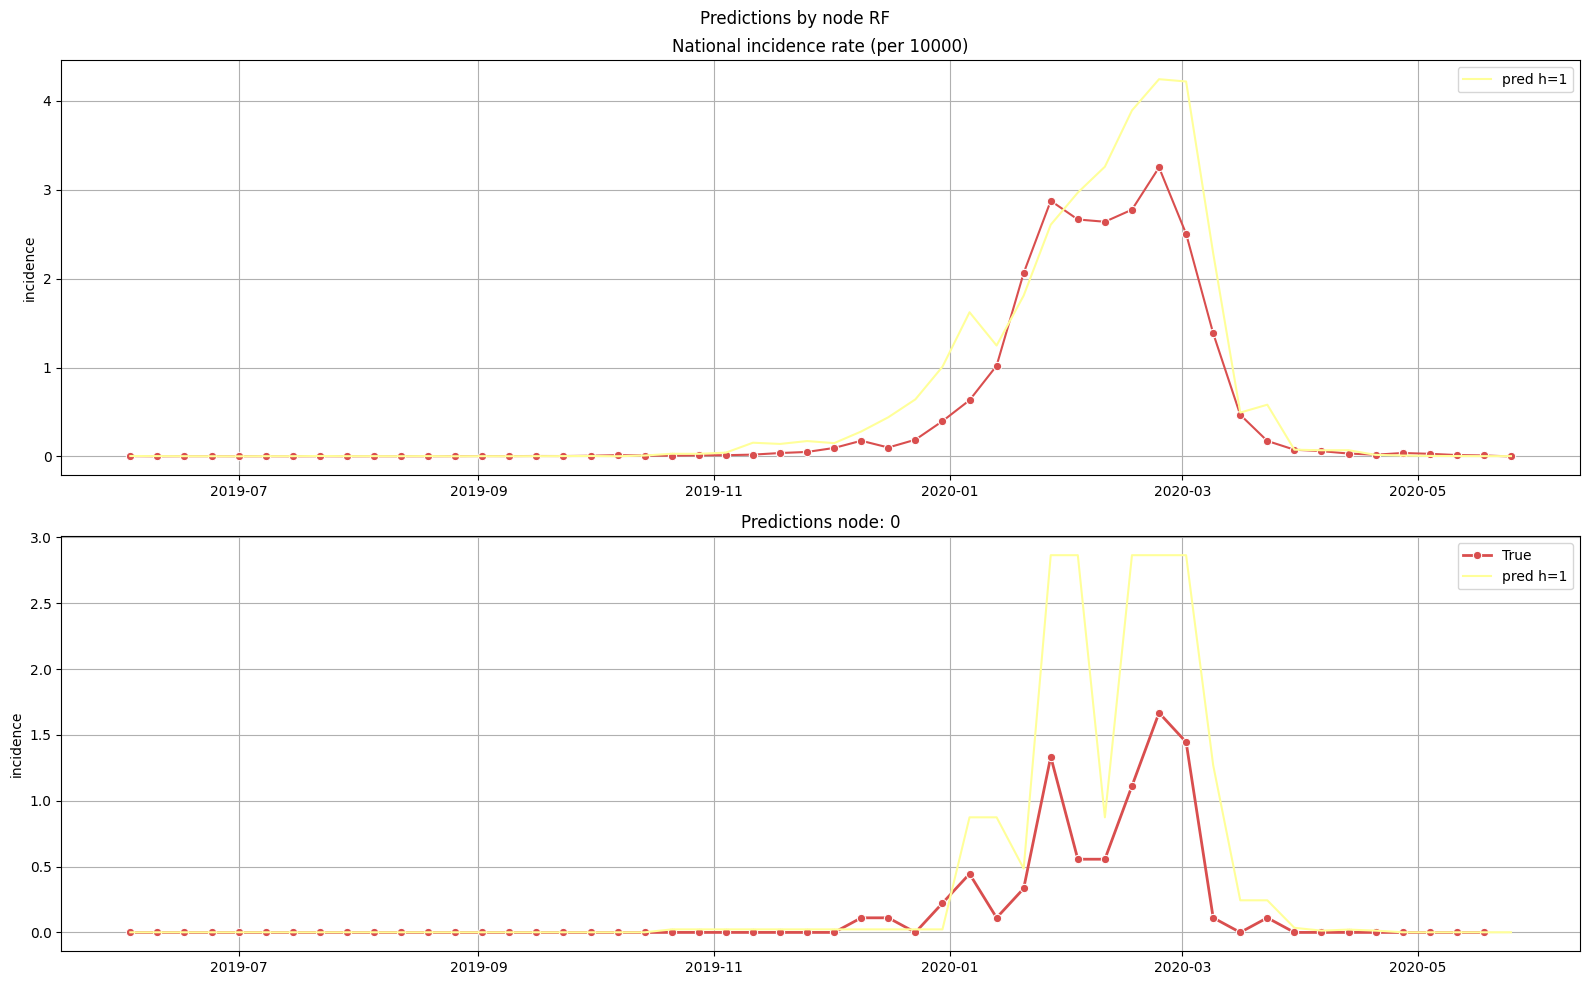

In [59]:
rfmodel.show_forecasts('test',0, target_h=1)

In [3]:
from src.evaluation import Evaluator

evallign = Evaluator([rfmodel], 1 )
evallign.add_evaluation(0)
evallign.add_evaluation(1)
evallign.add_evaluation(2)
evallign.add_evaluation(3)


Evaluator of ['node RF']

/home/de-schrijvers/projects/germany_gnn/src/evaluation/evaluator.py:153: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/home/de-schrijvers/projects/germany_gnn/src/evaluation/evaluator.py:153: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/home/de-schrijvers/projects/germany_gnn/src/evaluation/evaluator.py:153: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/home/de-schrijvers/projects/germany_gnn/src/evaluation/evaluator.py:153: UserWarning: set_ticklabels() should only be used with a fixed number of tick

Evaluator of ['node RF']

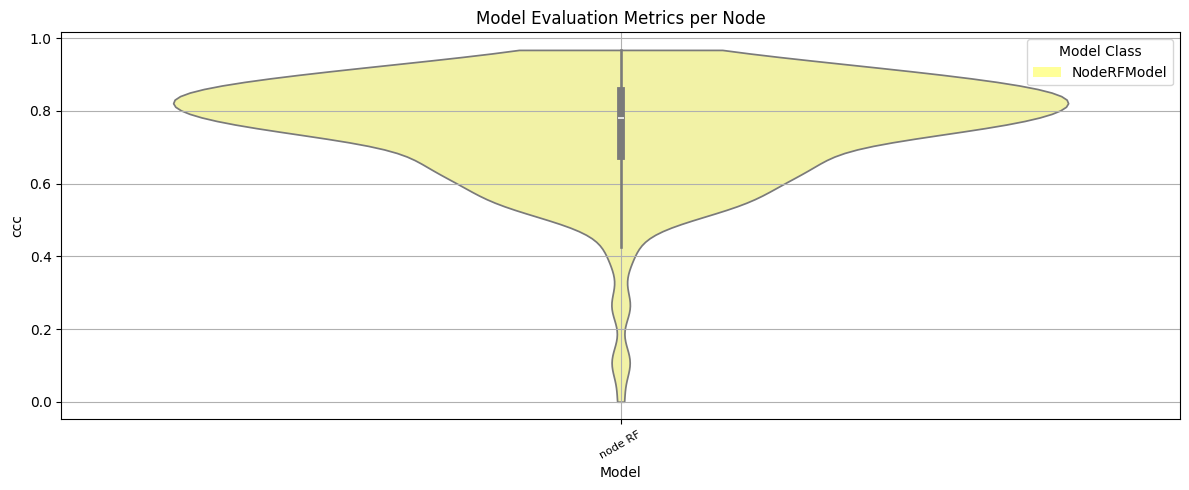

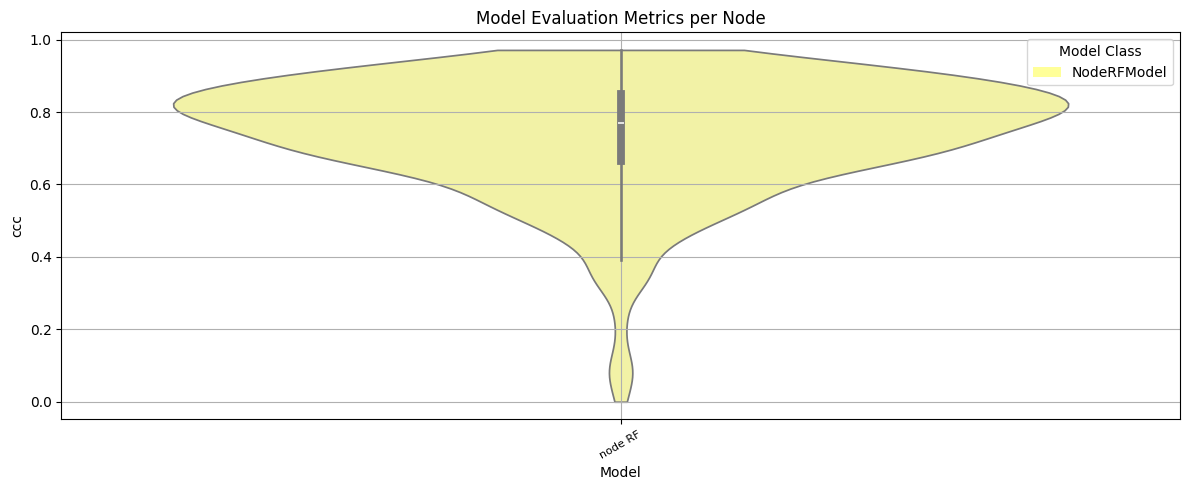

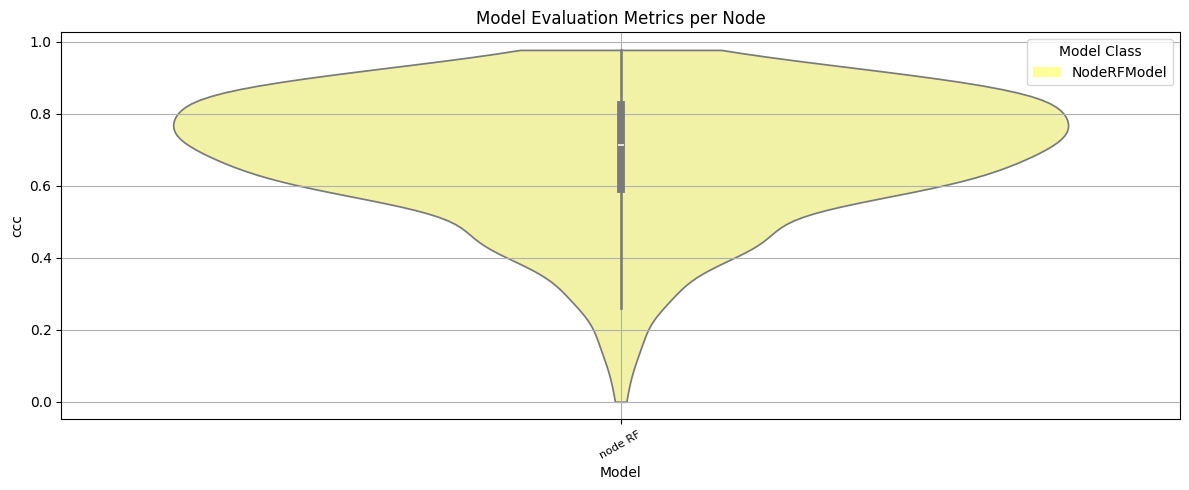

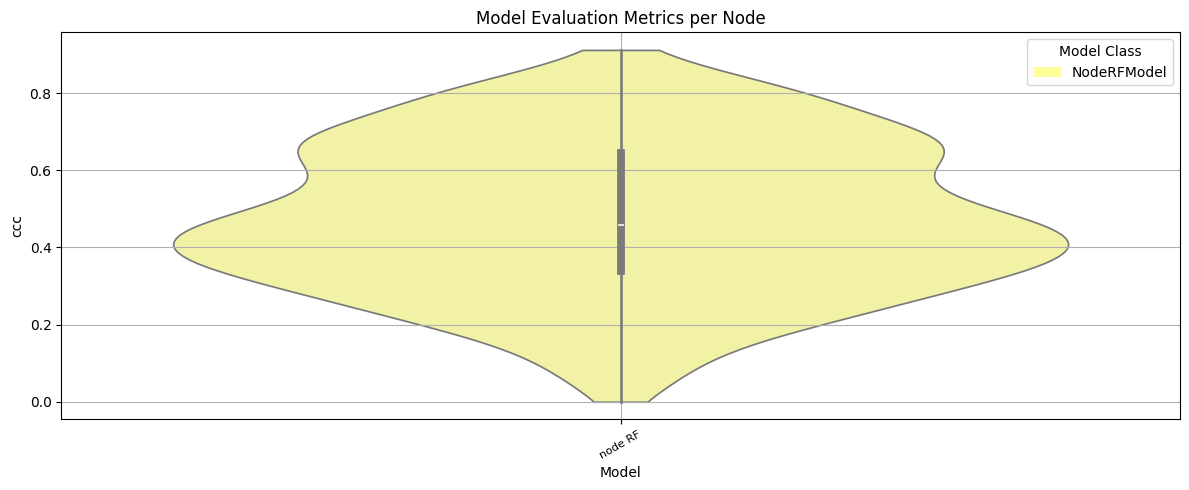

In [4]:
evallign.plot_metric('ccc',0)
evallign.plot_metric('ccc',1)
evallign.plot_metric('ccc',2)
evallign.plot_metric('ccc',3)